<a href="https://colab.research.google.com/github/Numpaque4/pryngles-numpaque/blob/kiss/transit_system_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Installing `Pryngles`**

In [1]:
!pip install -q git+https://github.com/Numpaque4/pryngles-numpaque

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import pryngles as pr



---



In [ ]:
!pip install -Uq pryngles

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 19.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import pryngles as pr

#**External Validation Code**

## `facom/exorings`

In [3]:
!git clone http://github.com/facom/exorings.git

Cloning into 'exorings'...
remote: Enumerating objects: 85, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 85 (delta 29), reused 85 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (85/85), 54.19 KiB | 18.06 MiB/s, done.
Resolving deltas: 100% (29/29), done.


In [4]:
import lib2to3
from lib2to3.refactor import RefactoringTool, get_fixers_from_package

# Function to apply 2to3 conversion
def convert_to_python3(file_path):
    tool = RefactoringTool(get_fixers_from_package("lib2to3.fixes"))
    tool.refactor_file(file_path, write=True)

# Convert the script
convert_to_python3("exorings/exorings.py")
convert_to_python3('exorings/exorings-basic.py')

In [5]:
!python exorings/exorings.py

All tests passed. Code ready to be used.


## `GeoTrans`

In [18]:
!git clone https://github.com/seap-udea/GeoTrans.git

Cloning into 'GeoTrans'...
remote: Enumerating objects: 231, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 231 (delta 21), reused 49 (delta 12), pack-reused 170 (from 1)
Receiving objects: 100% (231/231), 10.21 MiB | 21.83 MiB/s, done.
Resolving deltas: 100% (117/117), done.


In [30]:
convert_to_python3("GeoTrans/geotrans.py")

%cd GeoTrans
import geotrans as geo

%cd ..

/content/GeoTrans


#**External Packages**

In [6]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

%matplotlib inline



---

#**System Parameters**



In [257]:
#Star Parameters
Ms = 1.818855e+30 #Kg
Rs = 6.050039e+08 #Meters

#Planet Parameters
Mp = 1.147865e-05*Ms #Mstar
Rp = 1.598212e-02*Rs #Rstar

#Ring Parameters
opacity = 1
# i_ring = 74.6*pr.DEG #Deg
# roll = 56.9*pr.DEG #Deg
fi, fe = 2, 6.452317 #Rplanet
roll = 0#np.arccos(1/fe) - 1*pr.DEG
i_ring = np.pi/2#np.arccos(1/fe) - 1*pr.DEG

#Orbit Parameters
e = 0
a = 2.408960e-01 #AU
inc = np.pi/2#89.93*pr.DEG #Deg

#Limb-Darkening Coeffs
limb_cf = [0,0]

##**1. `pryngles RingedPlanet`**

In [258]:
RP = pr.RingedPlanet(Nb = 0, Np = 987, Ns = 987, Nr = 1000,
                     Rint = fi, Rext = fe,
                     a = a, e = e, i = i_ring,
                     Rstar = Rs/pr.Consts.au,
                     Mstar = Ms/pr.Consts.msun,
                     Rplanet = Rp/pr.Consts.au,
                     eobs_ecl = [np.pi/2 + roll, np.pi/2 - inc],
                     physics = dict(limb_cs = limb_cf))

RP.taur = np.inf

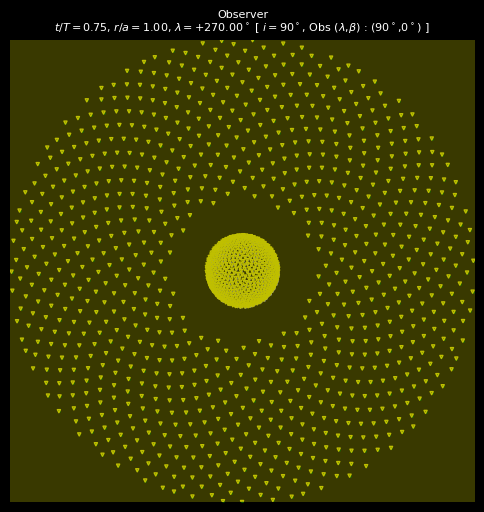

In [259]:
RP.changeStellarPosition(3*np.pi/2 + roll, kepler = False)
RP.plotRingedPlanet(showfig = False, showstar = True, axis = False)[1]

In [260]:
RP.updateOpticalFactors()
RP.updateTransit()

transit_RP = pd.Series([RP.Tip.sum(), RP.Tir.sum()],
                       index = ['Planet', 'Ring'])

##**2. `pryngles System`**

In [261]:
system = pr.System()

star = system.add(kind = "Star",
                  radius = Rs/system.ul,
                  m = Ms/system.um,
                  limb_coeffs = limb_cf)

planet = system.add(kind = "Planet", parent = star,
                    a = a, e = 0, radius = Rp/system.ul, m = 0)

ring = system.add(kind = "Ring", parent = planet,
                  fi = fi, fe = fe,
                  i = i_ring, roll = -roll)

In [262]:
# Setting Observer to the Ecplitic Plane
system.n_obs = pr.Science.direction(0, 90 - inc*pr.RAD)

# Configurating the System
system.initialize_simulation()
system.spangle_system()

In [263]:
taur_values = {name: np.inf #system.bodies[name].taur
              #  if system.bodies[name].kind == 'Ring'
              #  else np.inf
               for name in system.bodies}

system.data.tau_gray_optical = system.data.name.map(taur_values)

(-9.63201287425033e-10, -1.4217060782198148e-07)

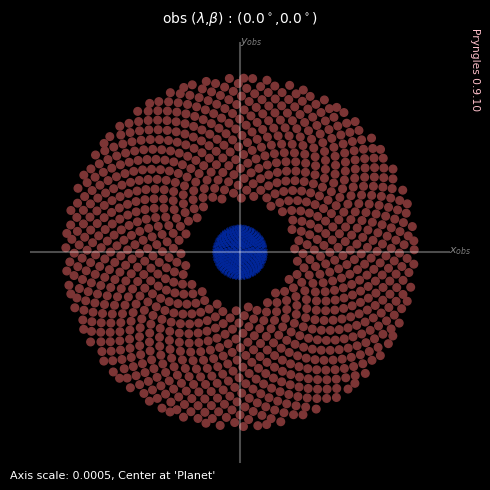

In [264]:
system.sg.plot2d(include = ['Planet', 'Ring'])

In [265]:
system.update_Transit()

transit_system = pd.Series(system.data.transit_flux.values,
                                  index = system.data.name
                                  ).groupby('name').sum()[['Planet', 'Ring']]

rhos_system = system.data.center_obs.iloc[-1][:2]/star.radius

nspangles_system = pd.Series(system.data.transit_over_obs.str.fullmatch(r'^Star[^&]*&$').values,
                             index = system.data.name).groupby('name').sum()[['Planet', 'Ring']]

##**3.** `facom/exorings`

In [266]:
!python exorings/exorings-basic.py fi={fi} fe={fe} theta={90-i_ring*pr.RAD} ir={-roll*pr.RAD} tau={100} p={Rp/Rs} P={RP.T*RP.CU.UT/pr.Consts.days} b={a*pr.Consts.au*np.cos(inc)/Rs}

Overrided parameters: P,b,p,fi,fe,tau,theta,ir.
************************************************************
 INPUT PARAMETERS 
************************************************************
Stellar properties:
	Stellar Density: rho_true = 1.41 g/cm^3.
Planetary properties:
	Planetary radius: p = Rp/R* = 0.0160.
Orbital properties:
	Orbital period: P = 45.1548 days.
	Impact parameter: b/R*= 0.0000
Ring properties:
	Internal Ring Radius: Ri/Rp = 2.000 Rp.
	External Ring Radius: Re/Rp = 6.452 Rp.
	Normal opacity: tau = 100.000.
	Projected inclination (90 deg for edge on): ir = 0.00 deg.
	Projected tilt: theta = 0.00 deg.
	Blocking factor: beta = 1.000000e+00.
************************************************************
 DERIVED PROPERTIES 
************************************************************
Orbital properties:
	Semimajor axis: a/R*= 53.3150
	Orbital Inclination: iorb = 90.000 deg
Ring derived properties:
	Projected exrenal ring axes: A/R* = 0.1031, B/R* = 0.1031
	Effective ring in

##**4.** `GeoTrans`

In [267]:
geo_system  =  geo.dict2obj(dict(

Ddet = 0.5,#Aperture, m
qeff = 1.0,#Quantum efficiency

Mstar = Ms,
Rstar = Rs,
Lstar = 0.7215989623093398*geo.LSUN,
Tstar = 5674,
Dstar = 783.831*geo.PARSEC,
c1 = 0,#Limb Darkening
c2 = 0,#Limb Darkening

ap = a*geo.AU,
ep = e,
iorb = inc,
wp = 0,

Mplanet = 0,
Rplanet = Rp,
fp = 0.0, #Oblateness

fe = fe, #Exterior ring (Rp)
fi = fi, #Interior ring (Rp)
ir = i_ring, #Ring inclination
phir = -roll, #Ring roll angle
tau = np.inf, #Opacity
))

geo.derivedSystemProperties(geo_system)
geo.updatePlanetRings(geo_system)
geo.updatePosition(geo_system, geo_system.tcen)

transit_geo = geo.transitArea(geo_system)



---

#**Transit Areas Validation**



In [279]:
print('RINGEDPLANET\n')

print(f'Transit Depth = {transit_RP.sum()}\n')
print(f'Nspangles = {(RP.Tip > 0).sum()}\nPlanet Area = {transit_RP[0]}\n')
print(f'Nspangles = {(RP.Tir > 0).sum()}\nRing Area = {transit_RP[1]}\n')

print(f'Expected Planet Area = {RP.Ap/np.pi}')
print(f'Expected Ring Area = {RP.Ar/np.pi}')
print(f'Ring Area Error = {(RP.Ar/np.pi - transit_RP[1])*100/RP.Ar/np.pi}')

print('-------------------------------------\n')

print('SYSTEM\n')

print(f'Transit Depth = {transit_system.sum()}\n')
print(f'Nspangles = {nspangles_system[0]}\nPlanet Area = {transit_system[0]}\n')
print(f'Nspangles = {nspangles_system[1]}\nRing Area = {transit_system[1]}\n')

print(f'Expected Planet Area = {(planet.radius/star.radius)**2}')
print(f'Expected Ring Area = {(ring.re**2 - ring.ri**2)/star.radius**2}')
print(f'Ring Area Error = {((ring.re**2 - ring.ri**2)/star.radius**2 - transit_system[1])*100/((ring.re**2 - ring.ri**2)/star.radius**2)}')

print('\n-------------------------------------\n')

print('GEOTRANS\n')

print(f'Transit Depth = {transit_geo[0]/np.pi}')
print(f'Planet Area = {transit_geo[1]/np.pi}')
print(f'Ring Area = {(transit_geo[0] - transit_geo[1])/np.pi}')

print('\n-------------------------------------\n')

print(f'Transit Error RP/Sys= {(transit_RP.sum() - transit_system.sum())*100/(transit_RP.sum())}')
print(f'Transit Error RP/Geo= {(transit_RP.sum() - transit_geo[0]/np.pi)*100/(transit_RP.sum())}')
print(f'Transit Error Sys/Geo= {(transit_system.sum() - transit_geo[0]/np.pi)*100/(transit_system.sum())}')

RINGEDPLANET

Transit Depth = 0.009867801474759897

Nspangles = 493
Planet Area = 0.00025542815969440005

Nspangles = 907
Ring Area = 0.009612373315065497

Expected Planet Area = 0.0002554281596944
Expected Ring Area = 0.009612373315065495
Ring Area Error = -1.8285207005292324e-15
-------------------------------------

SYSTEM

Transit Depth = 0.009867801474760036

Nspangles = 493
Planet Area = 0.0002554281596943997

Nspangles = 998
Ring Area = 0.009612373315065635

Expected Planet Area = 0.0002554281596944
Expected Ring Area = 0.009612373315065493
Ring Area Error = -1.4798356281809576e-12

-------------------------------------

GEOTRANS

Transit Depth = 0.009867801474759894
Planet Area = 0.0002554281596944
Ring Area = 0.009612373315065495

-------------------------------------

Transit Error RP/Sys= -1.4063707952892446e-12
Transit Error RP/Geo= 3.515926988223112e-14
Transit Error Sys/Geo= 1.4415300651714554e-12
